# Fiber gap repair -- interactive test bench

Tries out the functions in [fiberseg/tools/fiber_gap_repair.py](../fiberseg/tools/fiber_gap_repair.py) on a folder of prediction masks -- e.g. a `predict_all.py` `--out-dir` (or its `postprocessed/` subfolder) -- without running the full `python -m fiberseg.tools.fiber_gap_repair` CLI (which repairs+scores+saves every image in the config's split). Point `PRED_DIR` below at that folder and run all cells.

Covers:
- `repair_fiber_gaps()` end to end (oriented closing + collinearity-gated skeleton linking), with every parameter exposed for quick tuning.
- `oriented_closing()` in isolation, so you can see how much of the repair comes from the cheap closing pre-pass vs. the geodesic endpoint linking.
- A quick batch sanity check (fragment count / pixels added) across many masks at once, no files written.
- Optional scoring against ground truth (`evaluate_predictions.compute_metrics`), if you point it at a config.
- Optional `hysteresis_threshold_mask()` / `enhance_ridges()` demo -- these two work on a continuous probability map rather than a binary mask, which `predict_all.py` doesn't save to disk, so that section instead runs a live model prediction on the matching source image if you provide a checkpoint.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from skimage.measure import label
from skimage.morphology import remove_small_objects

from fiberseg.dataset import SPLIT_DIRS, _read_gray
from fiberseg.tools.fiber_gap_repair import (
    enhance_ridges,
    hysteresis_threshold_mask,
    oriented_closing,
    repair_fiber_gaps,
)

## Prediction mask directory

`PRED_DIR` should be a `predict_all.py` `--out-dir` (containing `train`/`validation`/`test` subfolders, per `SPLIT_DIRS`) or a flat folder of masks (e.g. from `predict_tiles.py`). Set `POSTPROCESSED = True` to test on `PRED_DIR/postprocessed/...` instead of the raw predictions.

In [2]:
PRED_DIR = Path("../predictions/UnetPlus SE_resnet152")  # predict_all.py's --out-dir
SUFFIX = "_pred.tif"  # prediction filename suffix, matching predict_all.py's --suffix
POSTPROCESSED = True  # True to browse PRED_DIR/postprocessed/<split> instead

base_dir = PRED_DIR / "postprocessed" if POSTPROCESSED else PRED_DIR
print(f"base_dir: {base_dir.resolve()}")

base_dir: C:\Users\lababr\Desktop\Sigurd\fiber_unet_trainer\predictions\UnetPlus SE_resnet152\postprocessed


In [3]:
def find_prediction_masks(base_dir: Path, suffix: str) -> list[tuple[str, Path, str]]:
    """Every prediction mask under base_dir's split subfolders (train/validation/
    test), falling back to a flat base_dir if none of those exist -- mirrors
    predict_all.py's output layout and fiber_gap_repair.py's own _find_prediction
    lookup. Returns (stem, path, split) tuples, split="unknown" for the flat fallback.
    """
    found = []
    seen = set()
    for split, folder in SPLIT_DIRS.items():
        split_dir = base_dir / folder
        if not split_dir.exists():
            continue
        for p in sorted(split_dir.glob(f"*{suffix}")):
            if p.name not in seen:
                seen.add(p.name)
                found.append((p.name[: -len(suffix)], p, split))
    if not found:
        for p in sorted(base_dir.glob(f"*{suffix}")):
            if p.name not in seen:
                seen.add(p.name)
                found.append((p.name[: -len(suffix)], p, "unknown"))
    return found


masks = find_prediction_masks(base_dir, SUFFIX)
if not masks:
    raise FileNotFoundError(f"No prediction masks found under {base_dir} with suffix {SUFFIX!r}.")

print(f"Found {len(masks)} prediction mask(s) under {base_dir.resolve()}")
for stem, path, split in masks[:10]:
    print(f"  [{split}] {stem}")
if len(masks) > 10:
    print(f"  ... {len(masks) - 10} more")

Found 296 prediction mask(s) under C:\Users\lababr\Desktop\Sigurd\fiber_unet_trainer\predictions\UnetPlus SE_resnet152\postprocessed
  [train] A100 - Site 19
  [train] A100 - Site 20
  [train] A100 - Site 3
  [train] A104 - Site 22
  [train] A104 - Site 2
  [train] A104 - Site 44
  [train] A104 - Site 5
  [train] A106 - Site 6
  [train] A110 - Site 29
  [train] A110 - Site 37
  ... 286 more


## Pick one mask to test on

In [9]:
IMAGE_STEM = "A44 - Site 13" # e.g. "sample01" -- leave None to use the first mask found

if IMAGE_STEM is None:
    stem, mask_path, split = masks[0]
else:
    stem, mask_path, split = next((m for m in masks if m[0] == IMAGE_STEM), (None, None, None))
    if mask_path is None:
        raise FileNotFoundError(f"No prediction mask found for stem {IMAGE_STEM!r} in {base_dir}")

raw_mask = _read_gray(mask_path) > 0
print(f"Testing on: {stem}  (split={split})")
print(f"Mask shape: {raw_mask.shape}, foreground fraction: {100 * raw_mask.mean():.3f}%")

Testing on: A44 - Site 13  (split=test)
Mask shape: (1408, 2048), foreground fraction: 0.757%


## Repair parameters

See `repair_fiber_gaps`'s docstring for the full pipeline description. Short version: `max_gap`/`max_angle_deg` gate which fragment pairs are even considered for linking (distance and collinearity of their skeleton-endpoint tangents); `min_object_size` discards tiny noise specks before repair; `use_oriented_closing`/`closing_radius`/`closing_bins` control the cheap directional-closing pre-pass that runs before the endpoint linking.

In [10]:
MAX_GAP = 15
MAX_ANGLE_DEG = 30.0
MIN_OBJECT_SIZE = 10
CONNECTOR_WIDTH = 1
USE_ORIENTED_CLOSING = True
CLOSING_RADIUS = 4
CLOSING_BINS = 8

## Run the repair pipeline

Runs `oriented_closing()` on its own (to isolate its contribution) and `repair_fiber_gaps()` end to end (closing + endpoint linking), both starting from the same small-object-filtered mask, then reports how many fragments/pixels each stage adds.

In [11]:
cleaned = (
    remove_small_objects(raw_mask, max_size=MIN_OBJECT_SIZE - 1)
    if MIN_OBJECT_SIZE > 0 else raw_mask
)
closed_only = (
    oriented_closing(cleaned, radius=CLOSING_RADIUS, n_bins=CLOSING_BINS)
    if USE_ORIENTED_CLOSING else cleaned
)
repaired = repair_fiber_gaps(
    raw_mask,
    probability=None,
    max_gap=MAX_GAP,
    max_angle_deg=MAX_ANGLE_DEG,
    min_object_size=MIN_OBJECT_SIZE,
    connector_width=CONNECTOR_WIDTH,
    use_oriented_closing=USE_ORIENTED_CLOSING,
    closing_radius=CLOSING_RADIUS,
    closing_bins=CLOSING_BINS,
)

n_frag_raw = int(label(cleaned, connectivity=2).max())
n_frag_closed = int(label(closed_only, connectivity=2).max())
n_frag_repaired = int(label(repaired, connectivity=2).max())

print(f"Connected components -- raw: {n_frag_raw}, after closing: {n_frag_closed}, "
      f"after full repair: {n_frag_repaired}")
print(f"Pixels added by closing:         {int((closed_only & ~cleaned).sum())}")
print(f"Pixels added by endpoint linking: {int((repaired & ~closed_only).sum())}")

Connected components -- raw: 2, after closing: 2, after full repair: 2
Pixels added by closing:         1142
Pixels added by endpoint linking: 0


## Visualize

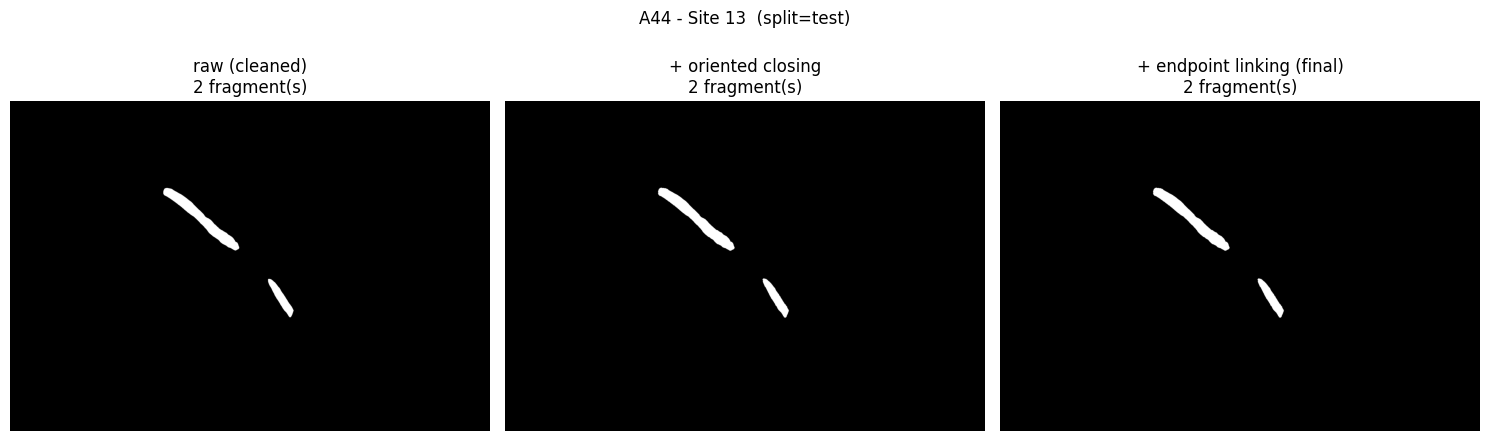

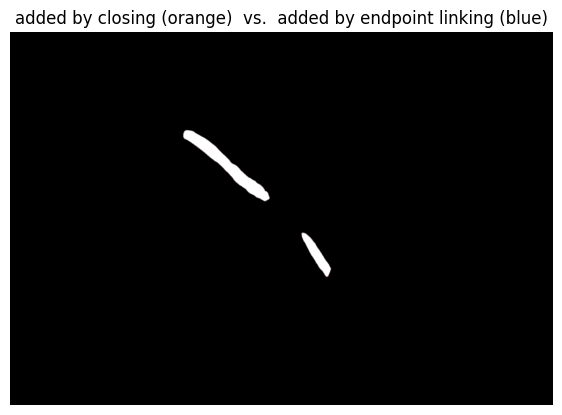

In [12]:
closing_added = closed_only & ~cleaned
linking_added = repaired & ~closed_only

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(cleaned, cmap="gray")
axes[0].set_title(f"raw (cleaned)\n{n_frag_raw} fragment(s)")
axes[1].imshow(closed_only, cmap="gray")
axes[1].set_title(f"+ oriented closing\n{n_frag_closed} fragment(s)")
axes[2].imshow(repaired, cmap="gray")
axes[2].set_title(f"+ endpoint linking (final)\n{n_frag_repaired} fragment(s)")
for ax in axes:
    ax.axis("off")
fig.suptitle(f"{stem}  (split={split})")
fig.tight_layout()
plt.show()

# What each stage added, overlaid on the final repaired mask.
fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(repaired, cmap="gray")
ax.imshow(np.ma.masked_where(~closing_added, closing_added), cmap="autumn", alpha=0.8)
ax.imshow(np.ma.masked_where(~linking_added, linking_added), cmap="cool", alpha=0.8)
ax.set_title("added by closing (orange)  vs.  added by endpoint linking (blue)")
ax.axis("off")
plt.show()

## Optional: score against ground truth

Set `CONFIG_PATH` to a project YAML config to look up the ground-truth mask for `stem` (via `data.masks_dir`/`data.mask_pattern`) and score raw vs. repaired with `evaluate_predictions.compute_metrics` (same tversky alpha/beta as training). Leave it `None` to skip.

In [ ]:
CONFIG_PATH = None  # e.g. "../configs/example.yaml"
MASKS_DIR = None  # override data.masks_dir from the config, if set
MASK_PATTERN = None  # override data.mask_pattern from the config, if set

if CONFIG_PATH is not None:
    import yaml

    from fiberseg.tools.evaluate_predictions import compute_metrics

    with open(CONFIG_PATH) as f:
        _cfg_dict = yaml.safe_load(f)

    masks_dir = Path(MASKS_DIR or _cfg_dict["data"]["masks_dir"])
    mask_pattern = MASK_PATTERN or _cfg_dict["data"].get("mask_pattern", "{stem}_mask.tif")
    alpha = _cfg_dict.get("train", {}).get("loss", {}).get("tversky_alpha", 0.3)
    beta = _cfg_dict.get("train", {}).get("loss", {}).get("tversky_beta", 0.7)

    gt_path = masks_dir / mask_pattern.format(
        stem=stem, suffix=mask_path.suffix, name=mask_path.name
    )
    if gt_path.exists():
        gt_mask = _read_gray(gt_path)
        raw_metrics = compute_metrics(
            cleaned.astype(np.uint8) * 255, gt_mask, alpha=alpha, beta=beta
        )
        repaired_metrics = compute_metrics(
            repaired.astype(np.uint8) * 255, gt_mask, alpha=alpha, beta=beta
        )
        for m in ("dice", "iou", "tversky", "precision", "recall", "f2"):
            print(f"{m:12s} raw={raw_metrics[m]:.4f}  repaired={repaired_metrics[m]:.4f}  "
                  f"delta={repaired_metrics[m] - raw_metrics[m]:+.4f}")
    else:
        print(f"No ground-truth mask found at {gt_path}, skipping scoring.")
else:
    print("CONFIG_PATH not set -- skipping ground-truth scoring.")

## Optional: batch sanity check across the folder

Runs the same repair parameters over multiple masks at once (no files written) and reports fragment-count and pixel-count deltas per image, as a quick check that the current parameters behave reasonably across the dataset before committing to a full `python -m fiberseg.tools.fiber_gap_repair` run (which also saves the repaired masks and a `metrics.csv`).

In [13]:
MAX_IMAGES_FOR_BATCH_CHECK = 20  # None to run over every mask found

batch_masks = masks if MAX_IMAGES_FOR_BATCH_CHECK is None else masks[:MAX_IMAGES_FOR_BATCH_CHECK]
batch_rows = []
for b_stem, b_path, b_split in batch_masks:
    b_raw = _read_gray(b_path) > 0
    b_cleaned = (
        remove_small_objects(b_raw, max_size=MIN_OBJECT_SIZE - 1)
        if MIN_OBJECT_SIZE > 0 else b_raw
    )
    b_repaired = repair_fiber_gaps(
        b_raw,
        probability=None,
        max_gap=MAX_GAP,
        max_angle_deg=MAX_ANGLE_DEG,
        min_object_size=MIN_OBJECT_SIZE,
        connector_width=CONNECTOR_WIDTH,
        use_oriented_closing=USE_ORIENTED_CLOSING,
        closing_radius=CLOSING_RADIUS,
        closing_bins=CLOSING_BINS,
    )
    batch_rows.append({
        "image": b_stem,
        "split": b_split,
        "fragments_before": int(label(b_cleaned, connectivity=2).max()),
        "fragments_after": int(label(b_repaired, connectivity=2).max()),
        "pixels_added": int((b_repaired & ~b_cleaned).sum()),
    })

batch_df = pd.DataFrame(batch_rows)
batch_df["fragments_merged"] = batch_df["fragments_before"] - batch_df["fragments_after"]
print(batch_df[["fragments_before", "fragments_after", "fragments_merged", "pixels_added"]].describe())
batch_df

       fragments_before  fragments_after  fragments_merged  pixels_added
count         20.000000        20.000000         20.000000     20.000000
mean          22.250000        22.050000          0.200000   5227.150000
std           28.244934        28.057225          0.410391   4464.286591
min            1.000000         1.000000          0.000000   1423.000000
25%            4.000000         3.750000          0.000000   2184.750000
50%            6.000000         6.000000          0.000000   2830.000000
75%           55.000000        54.250000          0.000000   9714.500000
max           73.000000        73.000000          1.000000  14723.000000


,image,split,fragments_before,fragments_after,pixels_added,fragments_merged
0,A100 - Site 19,train,1,1,2880,0
1,A100 - Site 20,train,1,1,2328,0
2,A100 - Site 3,train,2,2,2780,0
3,A104 - Site 22,train,7,7,2649,0
4,A104 - Site 2,train,4,4,3468,0
5,A104 - Site 44,train,5,5,4705,0
6,A104 - Site 5,train,6,6,1423,0
7,A106 - Site 6,train,4,3,2248,1
8,A110 - Site 29,train,7,7,3058,0
9,A110 - Site 37,train,5,5,2460,0


## Optional: `hysteresis_threshold_mask()` / `enhance_ridges()` on a live probability map

These two work on a *continuous* probability map, not a binary mask -- `predict_all.py` only saves the final thresholded mask, so there's nothing to load for them from `PRED_DIR`. Set `CONFIG_PATH` (if not already set above) and `CHECKPOINT_PATH` to run a live prediction on the source image matching `stem` and test both functions on the resulting probability map. Leave `CHECKPOINT_PATH` `None` to skip this section.

In [26]:
CHECKPOINT_PATH = "C:/Users/lababr/Desktop/Sigurd/fiber_unet_trainer/checkpoints/fiber-sem-micronet-improved-full/encoder_name=se_resnet152_20260729-234348/best-057-0.6644.ckpt"  # e.g. "../mlruns/<run_id>/artifacts/model/checkpoints/best.ckpt"
SOURCE_IMAGE_PATH = r"C:\Users\lababr\Desktop\Sigurd\Current Training Material - fibers only - Preproc\Images\A94 - Site 23.tif"  # override -- else looked up in the config's data.images_dir by stem
CONFIG_PATH = "C:/Users/lababr/Desktop/Sigurd/fiber_unet_trainer/configs/micronet/unetPlus_encoder_sweep_improved.yaml"  # e.g. "../configs/example.yaml"

if CHECKPOINT_PATH is not None and CONFIG_PATH is not None:
    from fiberseg.config import load_config
    from fiberseg.dataset import _normalize_image
    from fiberseg.predict_tiles import load_predictor, predict_prob

    cfg = load_config(CONFIG_PATH)
    if SOURCE_IMAGE_PATH is not None:
        image_path = Path(SOURCE_IMAGE_PATH)
    else:
        matches = list(Path(cfg.data.images_dir).glob(f"{stem}.*"))
        if not matches:
            raise FileNotFoundError(f"No source image found for stem {stem!r} in {cfg.data.images_dir}")
        image_path = matches[0]

    model, device = load_predictor(CHECKPOINT_PATH, cfg)
    img = _normalize_image(_read_gray(image_path))
    prob = predict_prob(img, model, cfg, device)

    normal_thr_mask = prob > 0.9

    hyst_mask = hysteresis_threshold_mask(
        prob, low= 0.3, high= 0.9
    )
    ridge_map = enhance_ridges(prob, method="frangi")

    fig, axes = plt.subplots(2, 2, figsize=(10,10))
    axes[0, 0].imshow(prob, cmap="viridis")
    axes[0, 0].set_title("probability map")
    axes[0, 1].imshow(hyst_mask, cmap="gray")
    axes[0, 1].set_title(f"hysteresis_threshold_mask\n(low={cfg.train.threshold * 0.5:.2f}, high={cfg.train.threshold:.2f})")
    axes[1, 0].imshow(ridge_map, cmap="magma")
    axes[1, 0].set_title("enhance_ridges (frangi)")
    axes[1, 1].imshow(normal_thr_mask, cmap="gray")
    axes[1, 1].set_title(f"normal threshold mask\n(threshold={cfg.train.threshold:.2f})")
    fig.tight_layout()
    plt.show()
else:
    print("CHECKPOINT_PATH/CONFIG_PATH not set -- skipping probability-map-based "
          "functions (hysteresis_threshold_mask, enhance_ridges).")

# Browse predictions: image / GT mask / prediction mask

`show_prediction(pred_dir)` opens a native, scrollable window over **every** image/mask/
prediction triplet in a `predict_all.py` output folder - click `< Prev`/`Next >`, or click
the window once then use the Left/Right arrow keys. Each pair shows its index, name,
train/validation/test split, and dice/iou/precision/recall/tversky/f2. A pair missing its
image/mask/prediction file is reported in place rather than stopping you from continuing
to browse past it.

Each pair can also be rated **bad / ok / good** (radio buttons, or the `b` / `o` / `g` keys
with the window focused - `u` clears back to unrated) and given a free-text comment via a
native pop-up dialog (click "Comment" or press `c`). Both autosave to `pair_ratings.csv`
next to this notebook, keyed by image name, so ratings persist across models/pred_dirs and
across notebook restarts.

**Note:** the comment field intentionally uses a native Tk dialog rather than an embedded
matplotlib text box - matplotlib's `TextBox` widget has a blinking-cursor timer that is
known to hang/spin indefinitely under the Tk backend in Jupyter on Windows.

**Note:** the cell below sets `%matplotlib tk`, switching this notebook's plotting
backend to native pop-up windows for every cell run *after* it. The inline plots earlier
in this notebook (histograms, scatter plots, etc.) aren't affected unless you re-run
those cells after this point.

In [ ]:
%matplotlib tk

from tkinter import simpledialog

from matplotlib.widgets import Button, RadioButtons

from fiberseg.dataset import SPLIT_DIRS, _normalize_image, _read_gray

image_dir = Path("C:\\Users\\lababr\\Desktop\\Sigurd\\Current Training Material - fibers only - Preproc\\Images")
mask_dir = Path("C:\\Users\\lababr\\Desktop\\Sigurd\\Current Training Material - fibers only - Preproc\\Masks")


class PredictionViewer:
    """Scrollable native window over every image/mask/prediction triplet in a
    predict_all.py output folder, with a per-pair "bad"/"ok"/"good" rating and a free-text
    comment that autosave to a CSV. Use `show_prediction()` below instead of constructing
    this directly.
    """

    RATING_OPTIONS = ["unrated", "bad", "ok", "good"]

    def __init__(
        self,
        pred_dir,
        *,
        images_dir=image_dir,
        masks_dir=mask_dir,
        mask_pattern: str = "{stem}_mask.tif",
        suffix: str = "_pred.tif",
        postprocessed: bool = False,
        ratings_path="pair_ratings.csv",
    ):
        self.pred_dir = Path(pred_dir)
        self.images_dir = Path(images_dir)
        self.masks_dir = Path(masks_dir)
        self.mask_pattern = mask_pattern
        self.suffix = suffix
        self.postprocessed = postprocessed

        # Rates/comments the *image+GT mask pair* itself, so they're shared across every
        # pred_dir you browse (default path is notebook-relative, not tied to pred_dir).
        self.ratings_path = Path(ratings_path)
        self.ratings = self._load_ratings()

        # Prefer metrics.csv for both the image order and per-image metrics/split;
        # fall back to scanning the split subfolders directly if it's missing.
        metrics_csv = self.pred_dir / "metrics.csv"
        self.metrics_df = pd.read_csv(metrics_csv) if metrics_csv.exists() else None
        self.order = (
            self.metrics_df["image"].tolist() if self.metrics_df is not None else self._scan_pred_dir()
        )
        if not self.order:
            raise FileNotFoundError(f"No predictions found under {self.pred_dir}")

        self.idx = 0
        self.fig, self.axes = plt.subplots(1, 3, figsize=(16, 7))
        self.fig.subplots_adjust(bottom=0.25, top=0.82)
        self.fig.canvas.manager.set_window_title(str(self.pred_dir))
        self.fig.canvas.mpl_connect("key_press_event", self._on_key)

        ax_prev = self.fig.add_axes([0.76, 0.03, 0.09, 0.06])
        ax_next = self.fig.add_axes([0.87, 0.03, 0.09, 0.06])
        self.btn_prev = Button(ax_prev, "< Prev")
        self.btn_next = Button(ax_next, "Next >")
        self.btn_prev.on_clicked(lambda _e: self._step(-1))
        self.btn_next.on_clicked(lambda _e: self._step(1))

        ax_radio = self.fig.add_axes([0.03, 0.03, 0.16, 0.18])
        ax_radio.set_title("rating  (b/o/g/u)", fontsize=9)
        self.radio = RadioButtons(ax_radio, self.RATING_OPTIONS)
        self.radio.on_clicked(self._on_rating)

        ax_comment_btn = self.fig.add_axes([0.24, 0.05, 0.18, 0.06])
        self.btn_comment = Button(ax_comment_btn, "\U0001F4AC Comment  (c)")
        self.btn_comment.on_clicked(lambda _e: self._prompt_comment())

        self._render()

    # -- ratings persistence -------------------------------------------------

    def _load_ratings(self) -> dict:
        if not self.ratings_path.exists():
            return {}
        df = pd.read_csv(self.ratings_path).fillna("")
        return {
            row["image"]: {"rating": row.get("rating", ""), "comment": row.get("comment", "")}
            for _, row in df.iterrows()
        }

    def _save_ratings(self) -> None:
        rows = [{"image": image, **data} for image, data in self.ratings.items()]
        rows.sort(key=lambda r: r["image"])
        pd.DataFrame(rows, columns=["image", "rating", "comment"]).to_csv(
            self.ratings_path, index=False
        )

    def _current_image(self) -> str:
        return self.order[self.idx]

    def _set_rating(self, label: str) -> None:
        entry = self.ratings.setdefault(self._current_image(), {"rating": "", "comment": ""})
        entry["rating"] = label
        self._save_ratings()
        self.radio.eventson = False
        self.radio.set_active(self.RATING_OPTIONS.index(label))
        self.radio.eventson = True

    def _on_rating(self, label: str) -> None:
        entry = self.ratings.setdefault(self._current_image(), {"rating": "", "comment": ""})
        entry["rating"] = label
        self._save_ratings()

    def _prompt_comment(self) -> None:
        # A native Tk dialog rather than matplotlib's TextBox widget - TextBox's
        # blinking-cursor timer is known to hang/spin under the Tk backend in Jupyter
        # on Windows, which is what made the old comment box freeze the notebook.
        image_name = self._current_image()
        entry = self.ratings.get(image_name, {"rating": "", "comment": ""})
        parent = self.fig.canvas.manager.window
        text = simpledialog.askstring(
            "Comment", f"Comment for {image_name}:", initialvalue=entry.get("comment", ""), parent=parent
        )
        if text is not None:
            entry = self.ratings.setdefault(image_name, {"rating": "", "comment": ""})
            entry["comment"] = text
            self._save_ratings()
            self._render()

    # -- navigation -----------------------------------------------------------

    def _scan_pred_dir(self) -> list[str]:
        names, seen = [], set()
        for split_folder in SPLIT_DIRS.values():
            variant_dir = (
                self.pred_dir / "postprocessed" / split_folder
                if self.postprocessed
                else self.pred_dir / split_folder
            )
            if not variant_dir.exists():
                continue
            for p in sorted(variant_dir.glob(f"*{self.suffix}")):
                stem = p.name[: -len(self.suffix)]
                matches = list(self.images_dir.glob(f"{stem}.*"))
                if matches and matches[0].name not in seen:
                    seen.add(matches[0].name)
                    names.append(matches[0].name)
        return names

    def _step(self, delta: int) -> None:
        self.idx = max(0, min(len(self.order) - 1, self.idx + delta))
        self._render()

    def _on_key(self, event) -> None:
        if event.key == "right":
            self._step(1)
        elif event.key == "left":
            self._step(-1)
        elif event.key in ("b", "1"):
            self._set_rating("bad")
        elif event.key in ("o", "2"):
            self._set_rating("ok")
        elif event.key in ("g", "3"):
            self._set_rating("good")
        elif event.key in ("u", "0"):
            self._set_rating("unrated")
        elif event.key == "c":
            self._prompt_comment()

    # -- rendering --------------------------------------------------------------

    def _render(self) -> None:
        for ax in self.axes:
            ax.clear()
            ax.axis("off")

        image_name = self.order[self.idx]
        header = f"[{self.idx + 1}/{len(self.order)}]  {image_name}"

        entry = self.ratings.get(image_name, {"rating": "", "comment": ""})
        rating = entry.get("rating") or "unrated"
        self.radio.eventson = False
        self.radio.set_active(self.RATING_OPTIONS.index(rating))
        self.radio.eventson = True
        comment = entry.get("comment", "")

        try:
            img_path = self.images_dir / image_name
            if not img_path.exists():
                raise FileNotFoundError(f"image not found: {img_path}")
            stem = img_path.stem

            mask_path = self.masks_dir / self.mask_pattern.format(
                stem=stem, suffix=img_path.suffix, name=img_path.name
            )
            if not mask_path.exists():
                raise FileNotFoundError(f"ground-truth mask not found: {mask_path}")

            metrics_row = None
            split = None
            if self.metrics_df is not None:
                match = self.metrics_df[self.metrics_df["image"] == image_name]
                if len(match):
                    metrics_row = match.iloc[0]
                    split = metrics_row.get("split")
            if split is None:
                # Fall back to whichever split subfolder actually holds the prediction.
                for s, folder in SPLIT_DIRS.items():
                    if (self.pred_dir / folder / f"{stem}{self.suffix}").exists():
                        split = s
                        break
            if split is None:
                raise FileNotFoundError("could not determine train/validation/test split")

            split_folder = SPLIT_DIRS.get(split, split)
            base = (
                self.pred_dir / "postprocessed" / split_folder
                if self.postprocessed
                else self.pred_dir / split_folder
            )
            pred_path = base / f"{stem}{self.suffix}"
            if not pred_path.exists():
                raise FileNotFoundError(f"prediction mask not found: {pred_path}")

            image = _normalize_image(_read_gray(img_path))
            gt_mask = _read_gray(mask_path) > 0
            pred_mask = _read_gray(pred_path) > 0

            metric_names = ["dice", "iou", "precision", "recall", "tversky", "f2"]
            prefix = "post_" if self.postprocessed else "raw_"
            metrics_parts = []
            if metrics_row is not None:
                for name in metric_names:
                    for col in (f"{prefix}{name}", name):
                        if col in metrics_row.index and pd.notna(metrics_row[col]):
                            metrics_parts.append(f"{name}={metrics_row[col]:.3f}")
                            break

            self.axes[0].imshow(image, cmap="gray", interpolation="nearest")
            self.axes[0].set_title(img_path.name)
            self.axes[1].imshow(gt_mask, cmap="gray", interpolation="nearest")
            self.axes[1].set_title("ground truth")
            self.axes[2].imshow(pred_mask, cmap="gray", interpolation="nearest")
            self.axes[2].set_title(f"prediction{' (postprocessed)' if self.postprocessed else ''}")

            title = f"{header}   |   split={split}"
            title += "\n" + ("   ".join(metrics_parts) if metrics_parts else "(no metrics found)")
        except FileNotFoundError as e:
            self.axes[1].text(0.5, 0.5, str(e), ha="center", va="center", wrap=True)
            title = f"{header}\n(skipped: {e})"

        if comment:
            title += f"\ncomment: {comment}"

        for ax in self.axes:
            ax.axis("off")
        self.fig.suptitle(title)
        self.fig.canvas.draw_idle()


def show_prediction(pred_dir, **kwargs) -> PredictionViewer:
    """Open a native, scrollable window over every image/mask/prediction triplet in
    `pred_dir` (a predict_all.py output folder, e.g. "../predictions/UnetPlus SE_resnet152").

    Click `< Prev`/`Next >`, or click the window once then use the Left/Right arrow
    keys, to step through every image found in `pred_dir/metrics.csv` (or, if that's
    missing, every prediction file under `pred_dir`'s split subfolders). Each pair
    shows its index, name, train/validation/test split, and dice/iou/precision/
    recall/tversky/f2 - handles both `evaluate_predictions.py`'s plain metric column
    layout and `predict_all.py`'s raw_*/post_*/delta_* layout. A pair missing its
    image/mask/prediction file is reported in place, not raised, so you can keep
    browsing past it.

    Each pair also gets a "bad"/"ok"/"good" rating (radio buttons, or press b/o/g/u -
    unrated - with the window focused) and a free-text comment via a native Tk dialog
    (click "Comment" or press c). Both autosave to `ratings_path` (default:
    `pair_ratings.csv` next to this notebook) keyed by image name, so ratings persist
    across pred_dir/model and across notebook restarts.

    `images_dir`/`masks_dir` default to this notebook's own `image_dir`/`mask_dir`
    (see the "Compute Image Metrics" section above). Pass `postprocessed=True` to
    browse the postprocessed masks + post_* metrics instead of the raw ones.
    """
    return PredictionViewer(pred_dir, **kwargs)

c:\Users\lababr\AppData\Local\anaconda3\envs\cnn_test\Lib\tkinter\__init__.py:861: UserWarning: Glyph 128172 (\N{SPEECH BALLOON}) missing from font(s) DejaVu Sans.
  func(*args)
c:\Users\lababr\AppData\Local\anaconda3\envs\cnn_test\Lib\tkinter\__init__.py:861: UserWarning: Glyph 128172 (\N{SPEECH BALLOON}) missing from font(s) DejaVu Sans.
  func(*args)


In [20]:
# Example: browse every prediction from the UnetPlus SE_resnet152 run
viewer = show_prediction("../predictions/UnetPlus SE_resnet152")

# Same folder, but browsing the postprocessed masks + post_* metrics instead
# viewer = show_prediction("../predictions/UnetPlus SE_resnet152", postprocessed=True)